# WHOOP Recovery Score - Exploratory Data Analysis

# 1.1 Environment Setup

In [1]:
import pandas as pd 
import numpy as np 
from sqlalchemy import create_engine, text
from sqlalchemy.orm import sessionmaker
import seaborn as sns
import matplotlib.pyplot as plt 
import time
from dotenv import load_dotenv
import os
import math

# 1.2 Database Connection

# 2.1 Database Connection to Supabase



In [2]:
load_dotenv(dotenv_path="../.env")

USER = os.getenv("DB_USER")
PASSWORD = os.getenv("DB_PASSWORD")
HOST = os.getenv("DB_HOST")
PORT = os.getenv("DB_PORT")
DBNAME = os.getenv("DB_NAME")

# Construct the SQLAlchemy connection string
DATABASE_URL = f"postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DBNAME}?sslmode=require"

# Create the SQLAlchemy engine
engine = create_engine(DATABASE_URL)

# Test the connection
try:
    with engine.connect() as connection:
        print("Connection successful!")
except Exception as e:
    print(f"Failed to connect: {e}")



Connection successful!


# 2.2 Data Retrieval with SQL

In [3]:

query = text(
    """SELECT 
        -- identifiers
        R.cycle_id
        , R.created_at::date  AS date

        -- recovery score
        , R.recovery_score

        -- physiological signals
        , R.resting_heart_rate
        , R.hrv_rmssd_milli
        , R.spo2_percentage
        , R.skin_temp_celsius

        -- sleep timing
        , S.start AS sleep_start
        , S.end AS sleep_end

        -- raw sleep stage millis (convert to hours in Python)
        , S.total_in_bed_time_milli
        , S.total_awake_time_milli
        , S.total_light_sleep_time_milli
        , S.total_slow_wave_sleep_time_milli
        , S.total_rem_sleep_time_milli

        -- sleep quality metrics
        , S.sleep_efficiency_percentage
        , S.sleep_consistency_percentage
        , S.sleep_performance_percentage
        , S.respiratory_rate
        , S.sleep_cycle_count
        , S.disturbance_count

        -- sleep debt
        , S.sleep_needed_baseline_milli
        , S.sleep_needed_need_from_recent_strain_milli

        -- daily strain
        , C.strain AS cycle_strain
        , C.average_heart_rate AS cycle_avg_heart_rate
        , C.max_heart_rate AS cycle_max_heart_rate
        , C.kilojoule AS cycle_kilojoule

    FROM 
        fact_recovery R
    LEFT JOIN 
        fact_activity_sleep S 
        ON R.sleep_id = S.sleep_id
    LEFT JOIN 
        fact_cycle C 
        ON R.cycle_id = C.cycle_id

    WHERE 
        1=1
        AND S.nap = FALSE
        AND S.total_no_data_time_milli < 0.1

    ORDER BY R.created_at ASC
        """)

df = pd.read_sql_query(query, con=engine)
df.head()

,cycle_id,date,recovery_score,resting_heart_rate,hrv_rmssd_milli,spo2_percentage,skin_temp_celsius,sleep_start,sleep_end,total_in_bed_time_milli,...,sleep_performance_percentage,respiratory_rate,sleep_cycle_count,disturbance_count,sleep_needed_baseline_milli,sleep_needed_need_from_recent_strain_milli,cycle_strain,cycle_avg_heart_rate,cycle_max_heart_rate,cycle_kilojoule
0,485128018,2024-01-01,39,63,55.290910,96.15385,35.300000,2024-01-01 01:29:28.064,2024-01-01 06:25:33.135,17764110,...,54.0,13.437500,3,8,27915179,534836,14.368253,78,186,11146.555
1,485691691,2024-01-02,63,60,63.988388,96.50000,NaN,2024-01-01 23:23:56.167,2024-01-02 05:29:42.835,21945707,...,61.0,13.828125,4,11,27915179,1960856,12.028449,79,185,10150.765
2,486293849,2024-01-03,52,62,55.371407,94.79412,34.600000,2024-01-02 22:53:21.257,2024-01-03 05:37:35.250,24253031,...,65.0,13.857422,5,9,27914873,1190903,5.601850,72,143,8887.534
3,486924019,2024-01-04,59,60,59.133987,95.75000,35.100000,2024-01-03 23:30:49.228,2024-01-04 07:34:50.589,29040400,...,78.0,13.535156,6,16,27914568,226990,12.666767,75,179,10591.021
4,487510229,2024-01-05,73,60,64.707344,95.37500,35.113335,2024-01-04 22:39:14.320,2024-01-05 07:29:53.066,31318679,...,83.0,13.525391,8,17,27914263,1375608,4.392954,69,130,8900.495


In [4]:
# Convert the millisecond columns into minutes for bettet interpretability and visualization in Python. 

df_wrangled = df.copy()
milli_cols = ['total_in_bed_time_milli',
               'total_awake_time_milli',
               'total_light_sleep_time_milli',
               'total_slow_wave_sleep_time_milli',
               'total_rem_sleep_time_milli',
               'sleep_needed_need_from_recent_strain_milli',
               'sleep_needed_baseline_milli'
               
               ]
for col in milli_cols:
    df_wrangled[col.replace('_milli', '_hours')] = df_wrangled[col] / 3600000

df_wrangled =df_wrangled.drop(columns=milli_cols)

df_wrangled['total_sleep_time_hours'] = df_wrangled['total_light_sleep_time_hours'] 
+ df_wrangled['total_slow_wave_sleep_time_hours'] 
+ df_wrangled['total_rem_sleep_time_hours']


cols = [
    # identifiers
    'cycle_id',
    'date',

    # recovery score
    'recovery_score',
    
    # physiological metrics
    'hrv_rmssd_milli',
    'resting_heart_rate',
    'spo2_percentage',
    'skin_temp_celsius',
    'respiratory_rate',
    
    # sleep duration
    'total_in_bed_time_hours',
    'total_awake_time_hours',
    
    # sleep stages (minutes)
    'total_light_sleep_time_hours',
    'total_slow_wave_sleep_time_hours',
    'total_rem_sleep_time_hours',
    'total_sleep_time_hours',
    
    # sleep quality
    'sleep_efficiency_percentage',
    'sleep_consistency_percentage',
    'sleep_performance_percentage',
    'sleep_cycle_count',
    'disturbance_count',
    
    # sleep timing
    'sleep_start',
    'sleep_end',
    
    # sleep debt
    'sleep_needed_baseline_hours',
    'sleep_needed_need_from_recent_strain_hours',
    
    # strain
    'cycle_strain',
    'cycle_avg_heart_rate',
    'cycle_max_heart_rate',
    'cycle_kilojoule',
]

df_wrangled = df_wrangled[cols]

df_wrangled.head()

,cycle_id,date,recovery_score,hrv_rmssd_milli,resting_heart_rate,spo2_percentage,skin_temp_celsius,respiratory_rate,total_in_bed_time_hours,total_awake_time_hours,...,sleep_cycle_count,disturbance_count,sleep_start,sleep_end,sleep_needed_baseline_hours,sleep_needed_need_from_recent_strain_hours,cycle_strain,cycle_avg_heart_rate,cycle_max_heart_rate,cycle_kilojoule
0,485128018,2024-01-01,39,55.290910,63,96.15385,35.300000,13.437500,4.934475,0.376511,...,3,8,2024-01-01 01:29:28.064,2024-01-01 06:25:33.135,7.754216,0.148566,14.368253,78,186,11146.555
1,485691691,2024-01-02,63,63.988388,60,96.50000,NaN,13.828125,6.096030,0.825116,...,4,11,2024-01-01 23:23:56.167,2024-01-02 05:29:42.835,7.754216,0.544682,12.028449,79,185,10150.765
2,486293849,2024-01-03,52,55.371407,62,94.79412,34.600000,13.857422,6.736953,0.368507,...,5,9,2024-01-02 22:53:21.257,2024-01-03 05:37:35.250,7.754131,0.330806,5.601850,72,143,8887.534
3,486924019,2024-01-04,59,59.133987,60,95.75000,35.100000,13.535156,8.066778,0.672917,...,6,16,2024-01-03 23:30:49.228,2024-01-04 07:34:50.589,7.754047,0.063053,12.666767,75,179,10591.021
4,487510229,2024-01-05,73,64.707344,60,95.37500,35.113335,13.525391,8.699633,0.825126,...,8,17,2024-01-04 22:39:14.320,2024-01-05 07:29:53.066,7.753962,0.382113,4.392954,69,130,8900.495


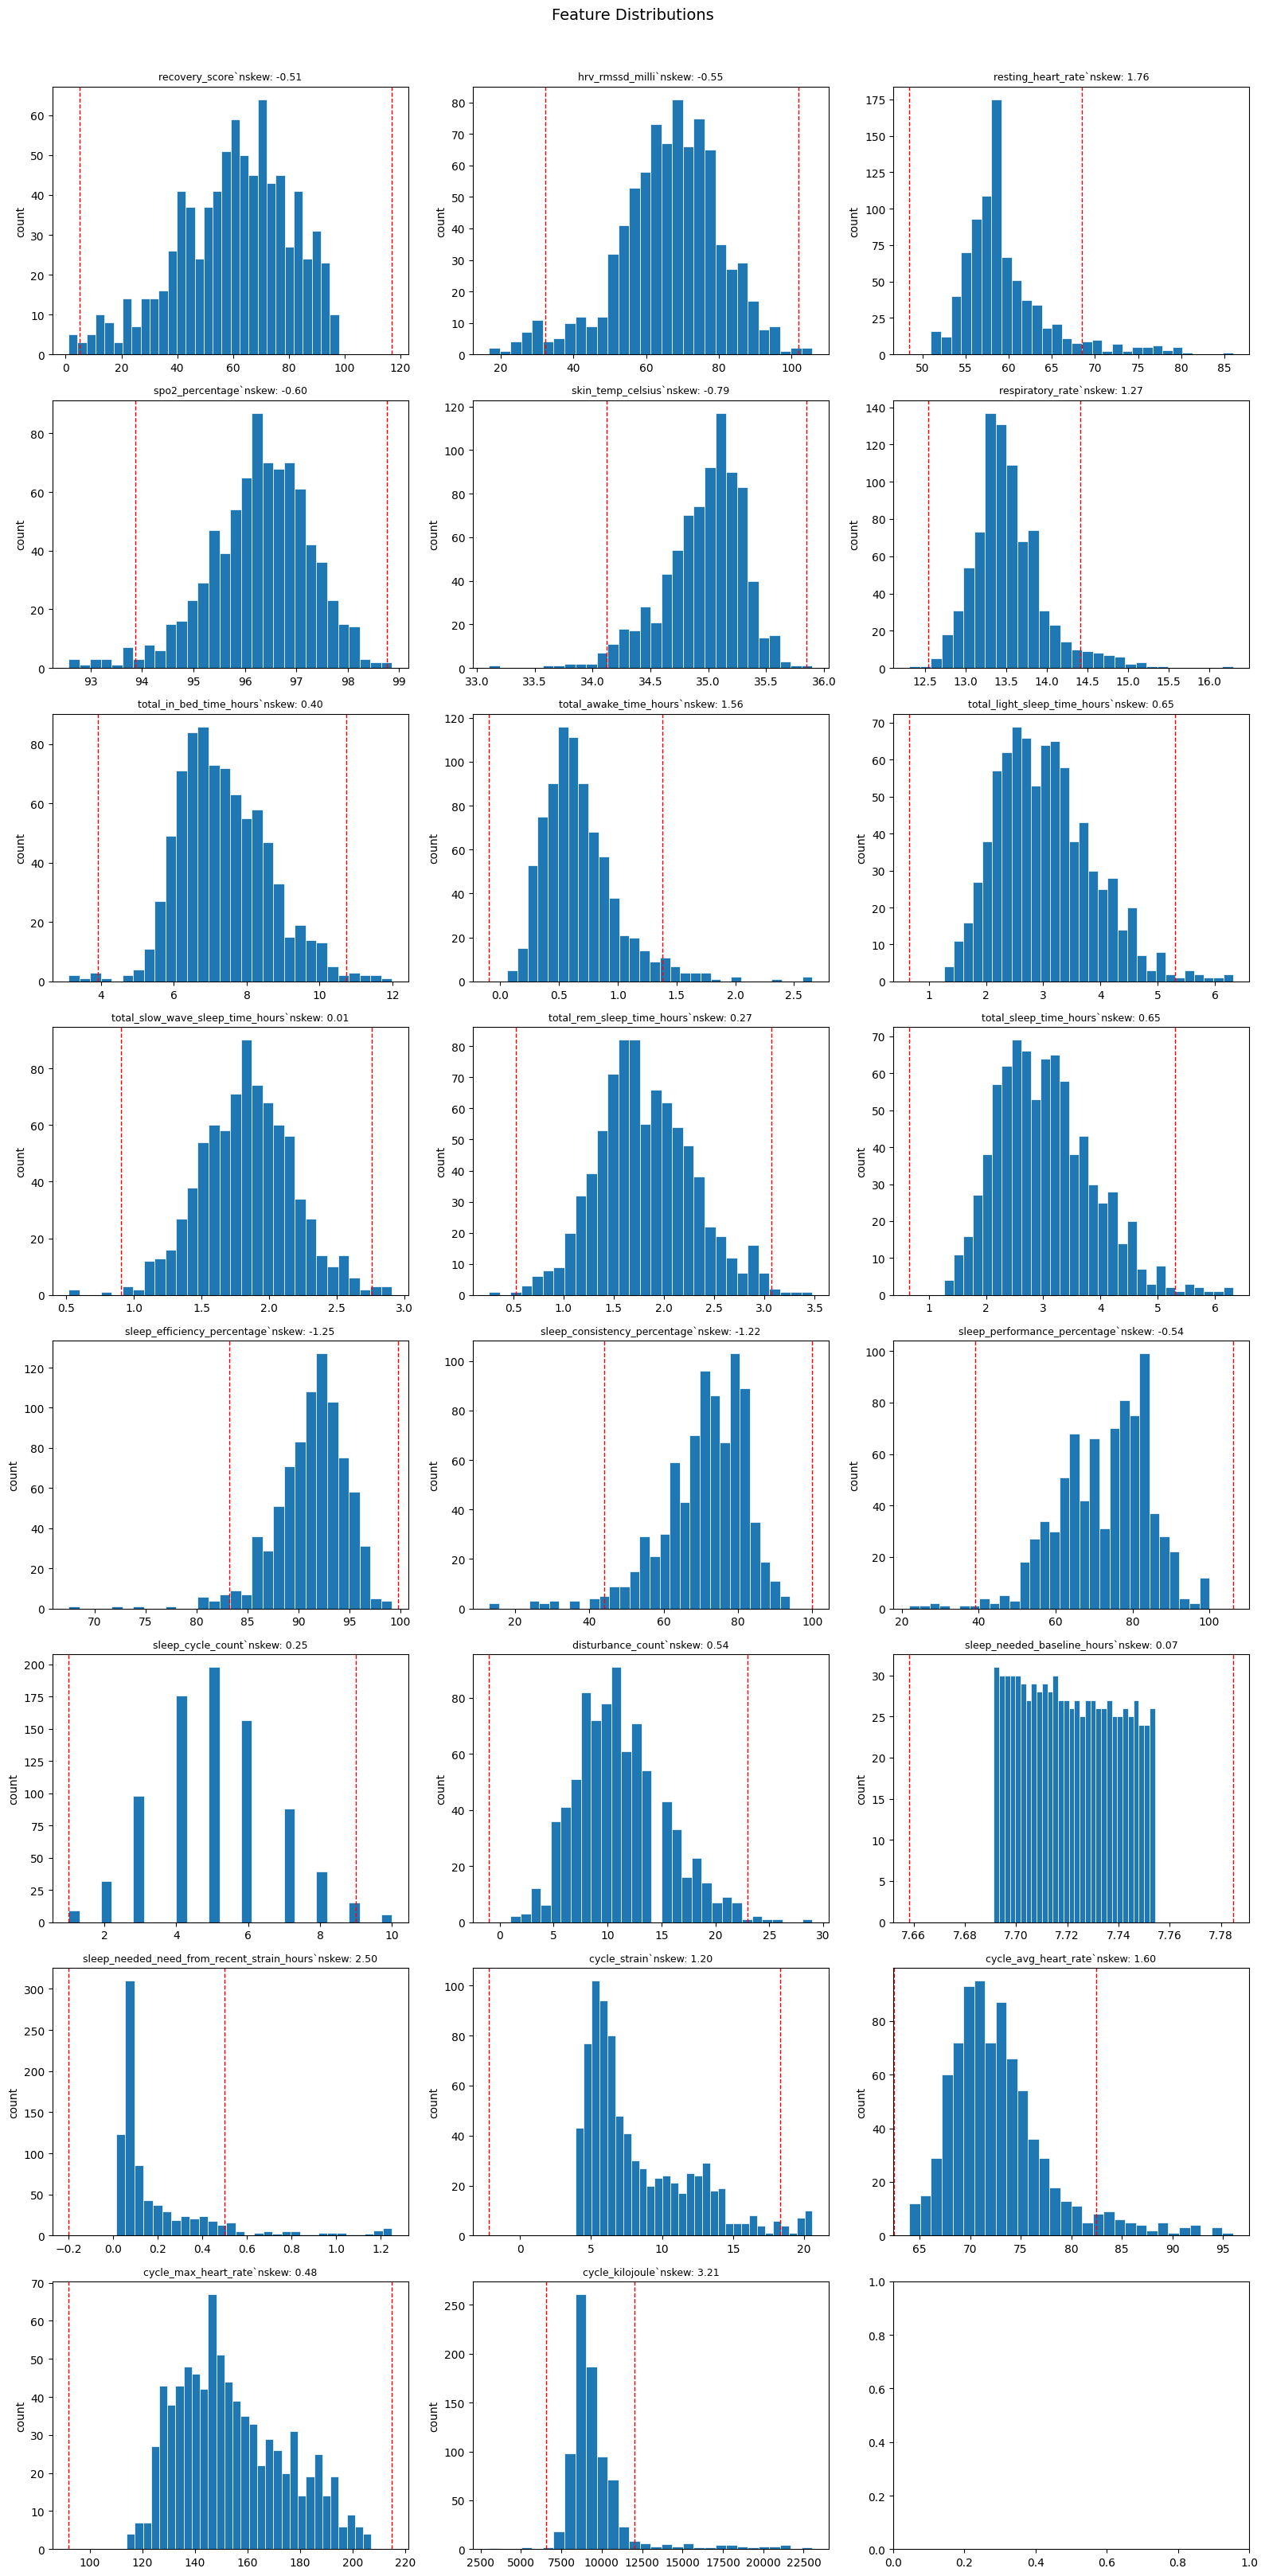

In [5]:
cols_distribution = [
    'recovery_score',
    
    # physiological metrics
    'hrv_rmssd_milli',
    'resting_heart_rate',
    'spo2_percentage',
    'skin_temp_celsius',
    'respiratory_rate',
    
    # sleep duration
    'total_in_bed_time_hours',
    'total_awake_time_hours',
    
    # sleep stages (minutes)
    'total_light_sleep_time_hours',
    'total_slow_wave_sleep_time_hours',
    'total_rem_sleep_time_hours',
    'total_sleep_time_hours',
    
    # sleep quality
    'sleep_efficiency_percentage',
    'sleep_consistency_percentage',
    'sleep_performance_percentage',
    'sleep_cycle_count',
    'disturbance_count',
    
    # sleep debt
    'sleep_needed_baseline_hours',
    'sleep_needed_need_from_recent_strain_hours',
    
    # strain
    'cycle_strain',
    'cycle_avg_heart_rate',
    'cycle_max_heart_rate',
    'cycle_kilojoule',
]

n_cols = 3
n_rows = math.ceil(len(cols_distribution) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_distribution):
    axes[i].hist(df_wrangled[col].dropna(), bins=30, edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('count')

    quartile_1 = df_wrangled[col].quantile(0.25)
    quartile_3 = df_wrangled[col].quantile(0.75)
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - 1.5 * iqr
    upper_bound = quartile_3 + 1.5 * iqr
    axes[i].axvline(lower_bound, color='red', linestyle='--', linewidth=1, label='lower bound')
    axes[i].axvline(upper_bound, color='red', linestyle='--', linewidth=1, label='upper bound')

    skew = df_wrangled[col].skew()
    axes[i].set_title(f'{col}`nskew: {skew:.2f}', fontsize = 9)


plt.suptitle('Feature Distributions', fontsize = 14, y=1.01)
plt.tight_layout()
plt.show()

## Observations from Facet Distribution Grid

the outliers for recovery and hrv are on the lower bound and very likely caused by alcohol consumption in combination with high physical activity (after playing cricket the day prior). These would likely provide noise within the model but will likely occur again in the furute, consider whether these should be included. An alcohol consumption flag could be added for outliers in both hrv and recovery score columns.

Low spo2 is likely through periods of illness and again, without logged data to support whether I was feeling ill, these should be treat with caution and removed from the analyses

Several metrics are positively skewed, with the primary candiate being sleep needed from recent strain with a score of 2.5. Considerations to log transform this metric should it be included within the model would be prudent

In [6]:
# Count of outliers in reovery and hrv based on iqr

q1_recovery = df_wrangled['recovery_score'].quantile(0.25)
iqr_recovery = df_wrangled['recovery_score'].quantile(0.75) - q1_recovery

lower_bound_recovery = q1_recovery - (iqr_recovery * 1.5)
print(f'lower bound recovery score: {lower_bound_recovery:.2f}')
upper_bound_recovery = q1_recovery + (iqr * 1.5)

lower_bound_outliers_recovery = df_wrangled[df_wrangled['recovery_score'] < lower_bound_recovery]

print(f'Number of outliers lower bound: {len(lower_bound_outliers_recovery)/ len(df_wrangled["recovery_score"]):.2%} ')

# HRV outliers
q1_hrv = df_wrangled['hrv_rmssd_milli'].quantile(0.25)
iqr_hrv = df_wrangled['hrv_rmssd_milli'].quantile(0.75) - q1_hrv

lower_bound_hrv = q1_hrv - (iqr_hrv * 1.5)
print(f'lower bound hrv score: {lower_bound_hrv:.2f}')

lower_bound_outliers_hrv = df_wrangled[df_wrangled['hrv_rmssd_milli'] < lower_bound_hrv]

print(f'Number of outliers lower bound: {len(lower_bound_outliers_hrv)/ len(df_wrangled["hrv_rmssd_milli"]):.2%} ')

lower_bound_outliers_hrv_recovery = df_wrangled[(df_wrangled['recovery_score'] < lower_bound_recovery) & (df_wrangled['hrv_rmssd_milli'] < lower_bound_hrv)]
print(f'Number of outliers lower bound: {len(lower_bound_outliers_hrv_recovery)} ')

lower bound recovery score: 5.00
Number of outliers lower bound: 0.61% 
lower bound hrv score: 32.20
Number of outliers lower bound: 3.06% 
Number of outliers lower bound: 4 


# Observations on outlier counts
Using the IQR is a very low threshold for both and likely a less than 5% recovery is much lower than most days following high strain and alcohol consumption.

Research provides detail of HRV decreasing by 28-33% in healthy subjects (Spaak et al 2010) with there being no protection for those that are physically active (Ralevski et al 2019).

Taking in the 28 - 33% decrease fromn the mean a threshold can be applied for low hrv days potentially caused by alochol and this can be used as a flag in combination with a low recovery score (< 34 red recovery in Whoop Scores)



In [7]:
hrv_median = df_wrangled['hrv_rmssd_milli'].median() # median is more robust to the outliers we know are present
low_hrv_threshold = hrv_median * 0.67 # more conservative requiring the larger decrease based on the study of 33% decrease 

print(low_hrv_threshold)

df_wrangled['alcohol_consumed_flag'] = ((df_wrangled['recovery_score'] < 34) & (df_wrangled['hrv_rmssd_milli'] < low_hrv_threshold)).astype(int)

df_wrangled[df_wrangled['alcohol_consumed_flag'] == 1].head()


45.16636696


,cycle_id,date,recovery_score,hrv_rmssd_milli,resting_heart_rate,spo2_percentage,skin_temp_celsius,respiratory_rate,total_in_bed_time_hours,total_awake_time_hours,...,disturbance_count,sleep_start,sleep_end,sleep_needed_baseline_hours,sleep_needed_need_from_recent_strain_hours,cycle_strain,cycle_avg_heart_rate,cycle_max_heart_rate,cycle_kilojoule,alcohol_consumed_flag
27,501479471,2024-01-28,8,29.129147,79,94.17647,34.731667,15.263672,6.656830,0.472643,...,13,2024-01-28 01:51:04.120,2024-01-28 08:30:29.671,7.751932,0.798018,9.569801,84,136,9487.1060,1
33,505803494,2024-02-04,29,40.553030,72,97.17647,35.400000,14.033203,6.560704,0.488670,...,10,2024-02-04 01:35:01.898,2024-02-04 08:10:07.912,7.751343,0.419062,5.224786,76,134,7748.6265,1
58,521515146,2024-02-29,10,30.013900,76,96.18750,35.000000,13.769531,7.562068,0.720984,...,6,2024-02-29 01:17:39.849,2024-02-29 08:52:21.933,7.749246,0.090616,13.369027,90,132,11972.9030,1
59,522245741,2024-03-01,14,29.114288,78,95.50000,35.100000,13.945312,6.240274,0.280381,...,8,2024-03-01 02:53:13.330,2024-03-01 09:07:39.277,7.749162,0.444801,5.344415,76,127,7591.3120,1
90,542180318,2024-04-01,17,43.392506,69,96.50000,35.036667,14.326172,7.522024,0.520718,...,10,2024-04-01 00:00:25.869,2024-04-01 07:33:41.472,7.746582,0.048350,12.057415,77,171,10655.5040,1


# Time Series analysis
Using matplotlibs time series graphs, I am looking for any seasonal trends in behaviour for metrics such as recovery scores, 

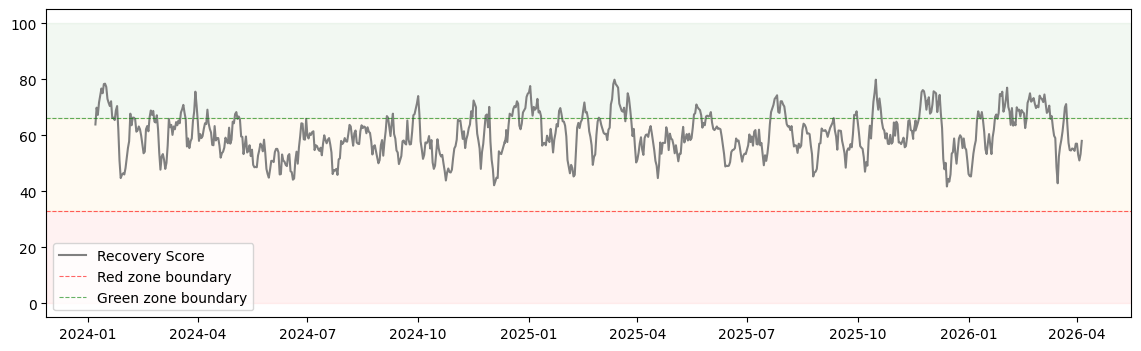

In [32]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_wrangled['date'], df_wrangled['recovery_score'].rolling(7).mean(), label='Recovery Score', color='gray')


ax.axhline(y=33, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='Red zone boundary')
ax.axhline(y=66, color='green', linestyle='--', linewidth=0.8, alpha=0.6, label='Green zone boundary')
ax.axhspan(0, 33, alpha=0.05, color='red')
ax.axhspan(33, 66, alpha=0.05, color='orange')
ax.axhspan(66, 100, alpha=0.05, color='green')
plt.legend(loc='lower left')
plt.show()

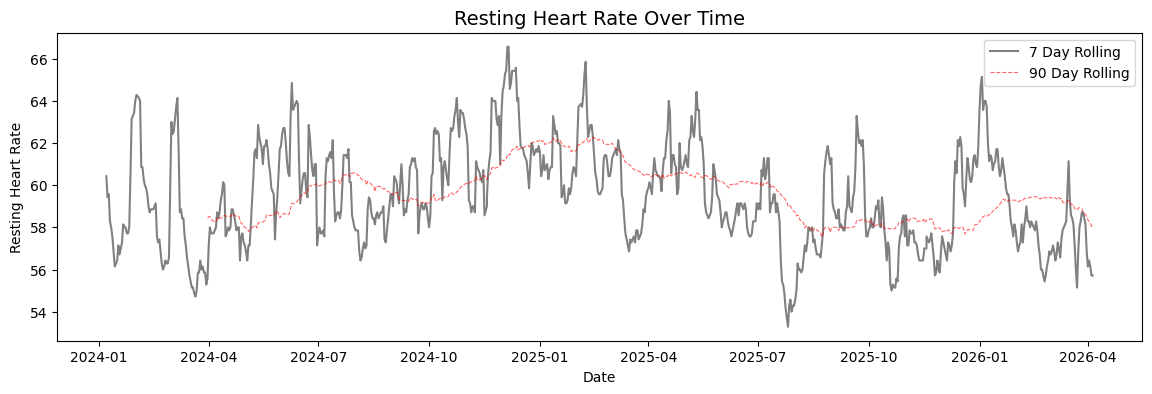

In [43]:
fig = plt.figure(figsize=(14,4))

plt.plot(df_wrangled['date'], df_wrangled['resting_heart_rate'].rolling(7).mean(), label='7 Day Rolling', color='gray')
plt.title('Resting Heart Rate Over Time', fontsize=14)
plt.plot(df_wrangled['date'], df_wrangled['resting_heart_rate'].rolling(90).mean(), color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='90 Day Rolling')
plt.xlabel('Date')
plt.ylabel('Resting Heart Rate')
plt.legend()
plt.show()

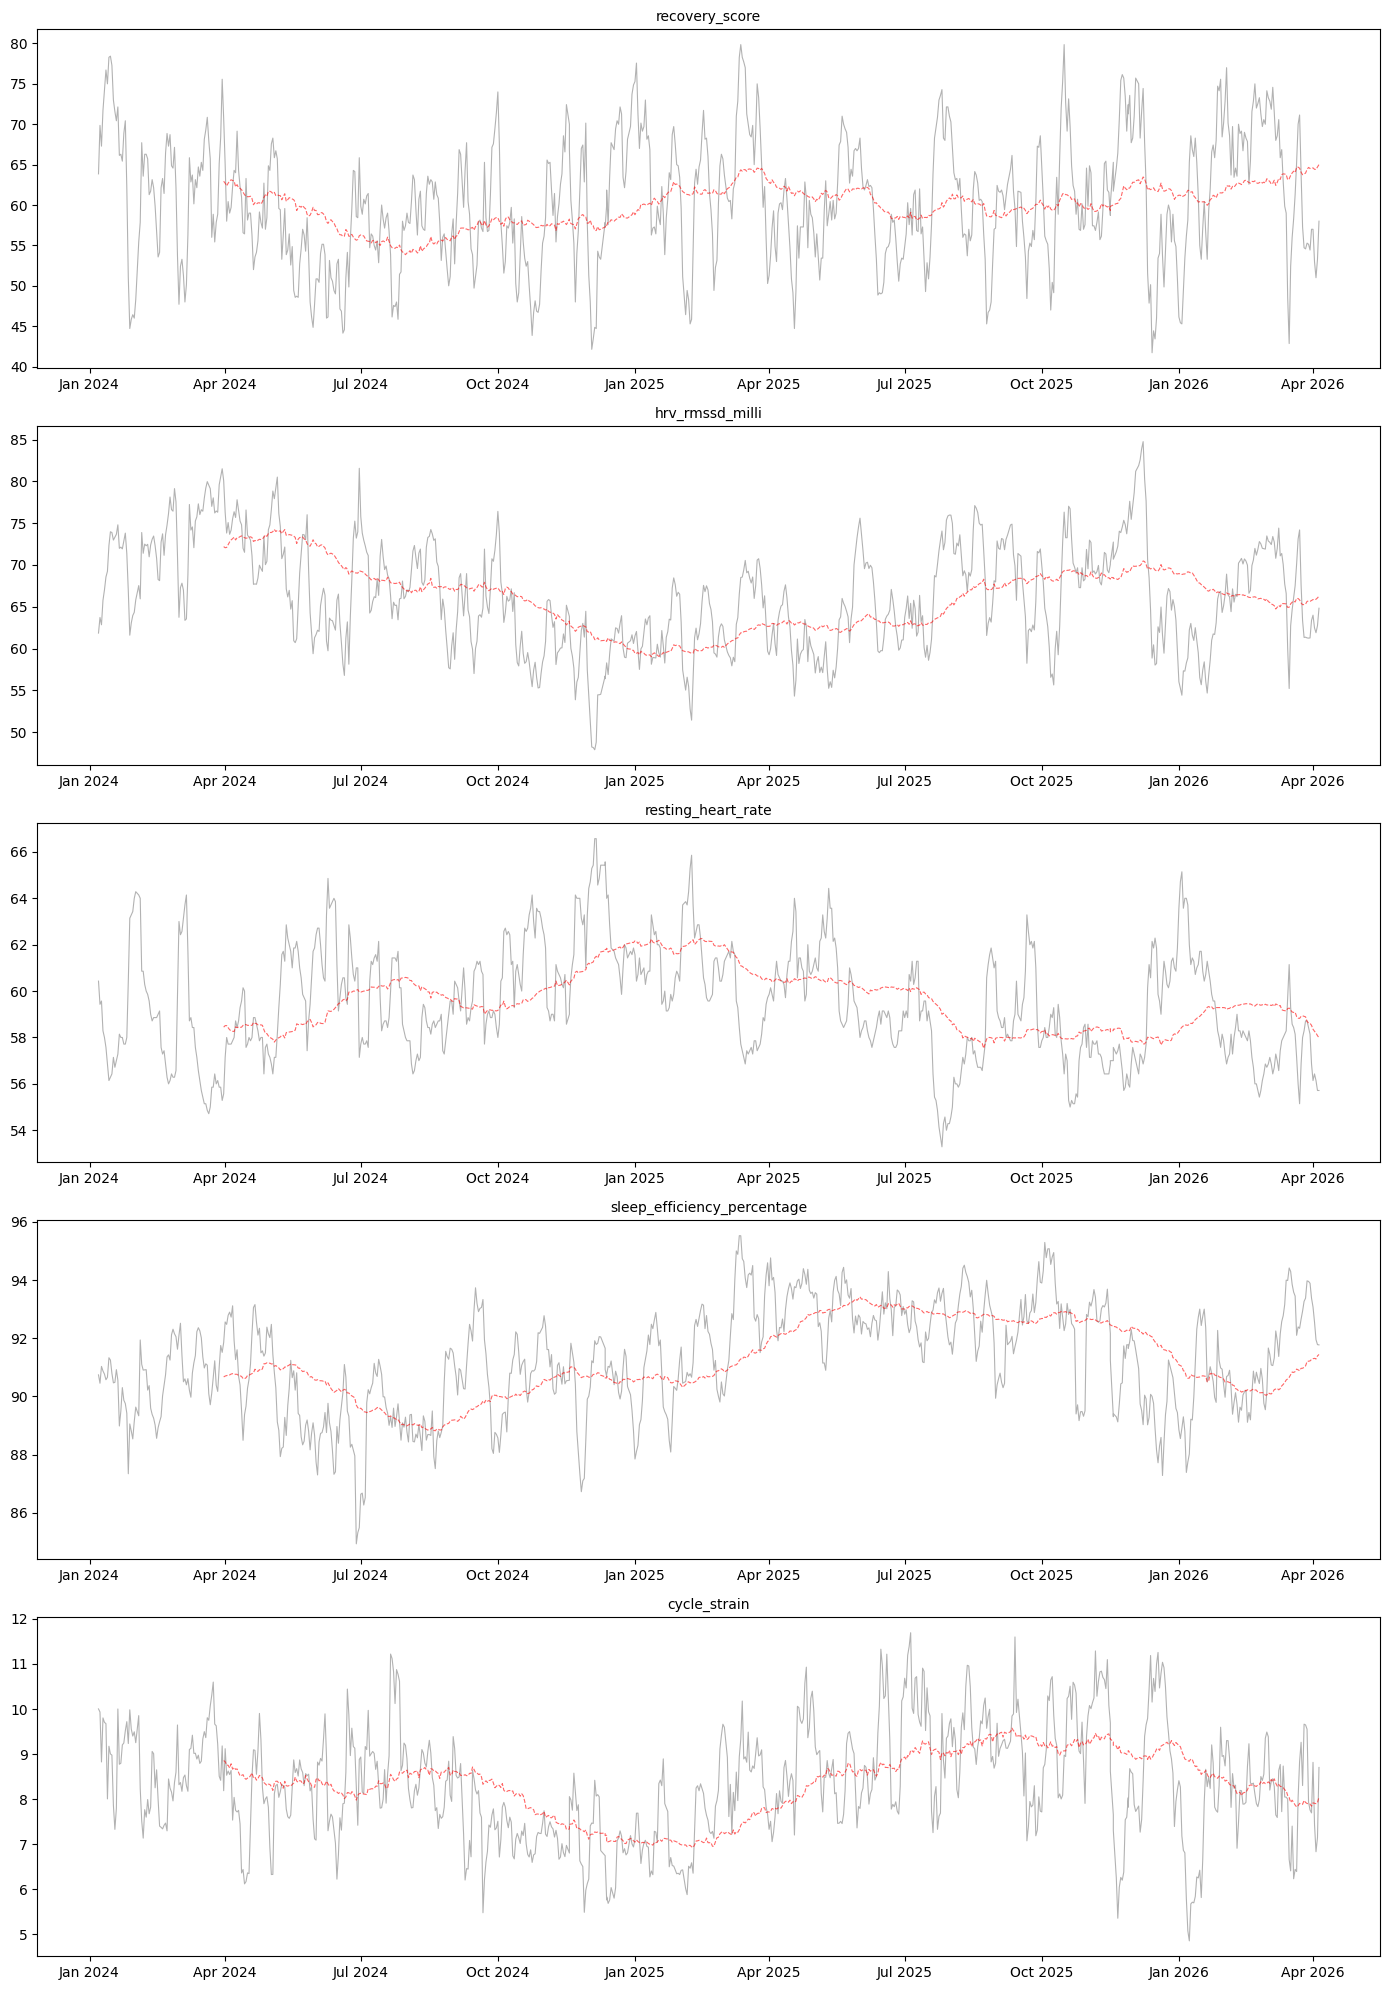

In [ ]:
time_series_cols = [
    'recovery_score',
    'hrv_rmssd_milli',
    'resting_heart_rate',
    'sleep_efficiency_percentage',
    'cycle_strain',
]

n_cols = 1
n_rows = len(time_series_cols)
fig,axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))

for i, col in enumerate(time_series_cols):
    axes[i].plot(df_wrangled['date'], df_wrangled[col].rolling(7).mean(), color='grey', linestyle='-', linewidth=0.8, alpha=0.6, label='7 Day Rolling')
    axes[i].plot(df_wrangled['date'], df_wrangled[col].rolling(90).mean(), color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='90 Day Rolling')
    axes[i].set_title(col, fontsize = 10)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    

plt.tight_layout()
plt.show()

# Investigating day of week and month of year impact
Anecdotally a lot of the high cycle strains will appear on a saturday through cricket season months within the UK (Apr to Sept)

This will also coincide with lower recoveries on a sunday due to the high strain and much higher probability of alcohol consumption

It is also expected that resting heart rate will decrease during summer months as fitness increases during the cricket season

The winter months (excl Dec) are much more likely to see less variance in the results due to reduced alcohol consumption in combination with less extreme values in cycle strain

As for day of weeks, it is expected that recoveries will be lower on Sundays, as well as wednesdays which are caused by increased sleep debt as a result of office days being tuesday and a wednesday. These typically feel to be the hardest days in terms of how the body feels, so it will be interesting to see how this impacts the data

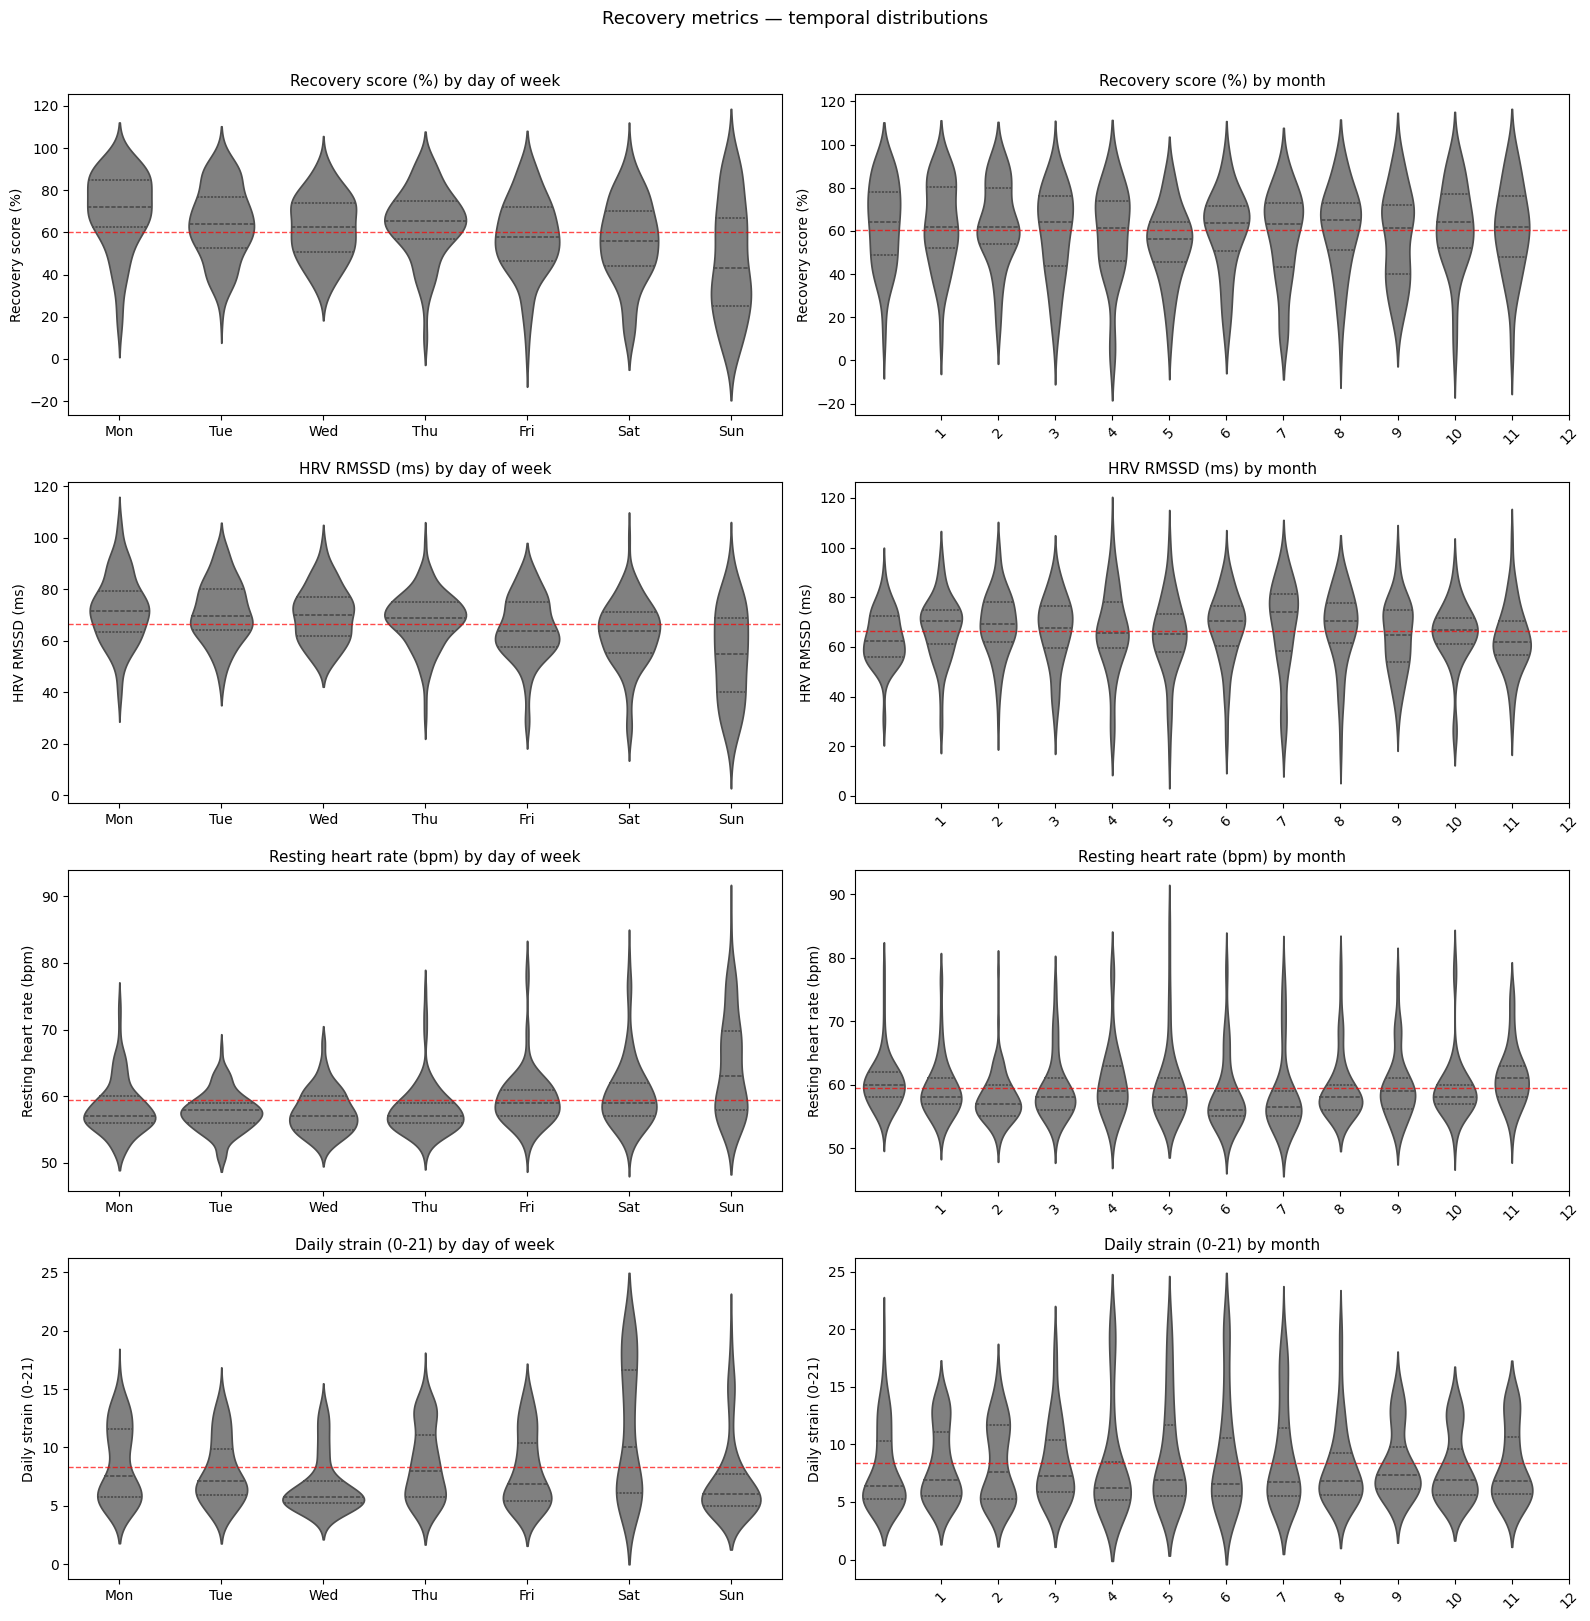

In [54]:
# Ensure day_of_week is extracted
df_wrangled['day_of_week'] = pd.to_datetime(df_wrangled['date']).dt.dayofweek

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

metrics = {
    'recovery_score': 'Recovery score (%)',
    'hrv_rmssd_milli': 'HRV RMSSD (ms)',
    'resting_heart_rate': 'Resting heart rate (bpm)',
    'cycle_strain': 'Daily strain (0-21)'
}

fig, axes = plt.subplots(len(metrics), 2, figsize=(16, len(metrics) * 4))

for i, (col, label) in enumerate(metrics.items()):

    # Day of week violin
    sns.violinplot(
        data=df_wrangled,
        x='day_of_week',
        y=col,
        ax=axes[i, 0],
        inner='quartile',
        color='gray',
    )
    axes[i, 0].set_xticks(range(7))
    axes[i, 0].set_xticklabels(day_labels)
    axes[i, 0].axhline(df_wrangled[col].mean(), color='red', 
                        linestyle='--', linewidth=1, alpha=0.7)
    axes[i, 0].set_title(f'{label} by day of week', fontsize=11)
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel(label)

    # Month violin
    sns.violinplot(
        data=df_wrangled,
        x='month',
        y=col,
        ax=axes[i, 1],
        inner='quartile',
        color='gray',
    )
    axes[i, 1].set_xticks(range(1, 13))
    axes[i, 1].set_xticklabels(df_wrangled['month'].unique(), rotation=45)
    axes[i, 1].axhline(df_wrangled[col].mean(), color='red',
                        linestyle='--', linewidth=1, alpha=0.7)
    axes[i, 1].set_title(f'{label} by month', fontsize=11)
    axes[i, 1].set_xlabel('')
    axes[i, 1].set_ylabel(label)

plt.suptitle('Recovery metrics — temporal distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Analysis of DOW & Month 
### Recovery score
Clear Degredation as the week progresses is apparrent in the data with the strongest recovery occuring on monday and the lowest on a sunday.


### HRV 
Follows the same patter 